<a href="https://colab.research.google.com/github/SakshiSindhe/Indian-Pharmaceutical-Export-Analysis/blob/main/CA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First five rows:
   Sr. No.  HS Code           HS Description  Country Name  \
0      1.0     30.0  PHARMACEUTICAL PRODUCTS         U S A   
1      2.0     30.0  PHARMACEUTICAL PRODUCTS        RUSSIA   
2      3.0     30.0  PHARMACEUTICAL PRODUCTS  SOUTH AFRICA   
3      4.0     30.0  PHARMACEUTICAL PRODUCTS       NIGERIA   
4      5.0     30.0  PHARMACEUTICAL PRODUCTS           U K   

  April-2019-20_INR_Cr April-2019-20_USD_Mn April-2020-21_INR_Cr  \
0            3,400.963              489.859            4,300.363   
1              251.497               36.225              221.593   
2              235.268               33.887              251.175   
3              221.405               31.890              112.339   
4              207.497               29.887              313.055   

  April-2020-21_USD_Mn April-2021-22_INR_Cr April-2021-22_USD_Mn  ...  \
0              564.082            3,932.031              527.986  ...   
1               29.067              310.290            

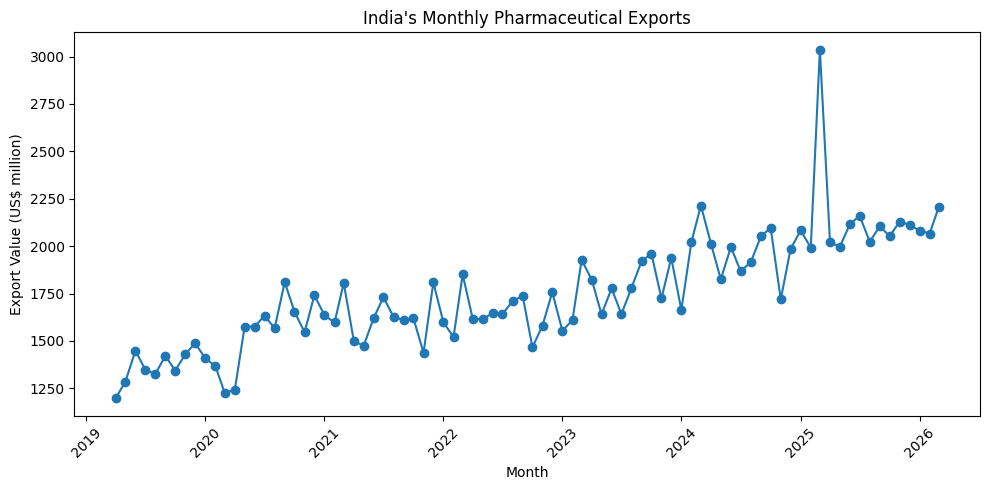

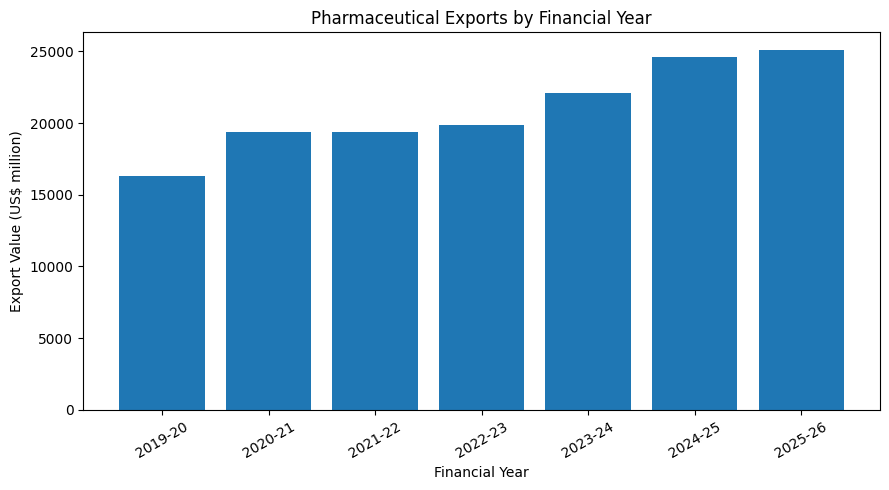

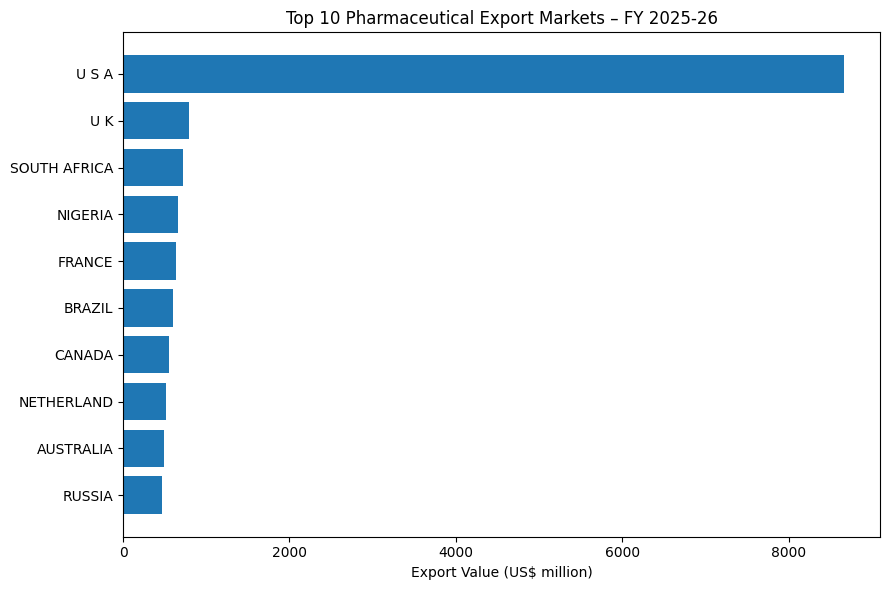

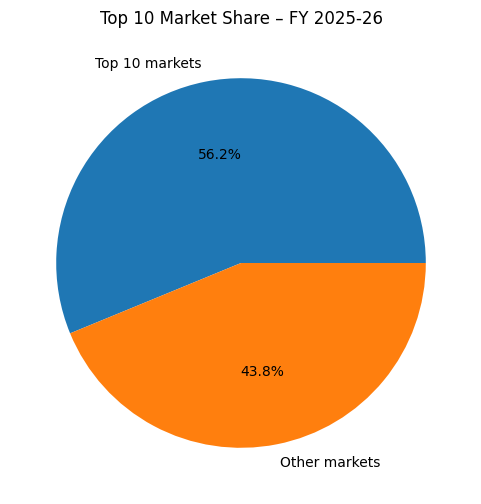

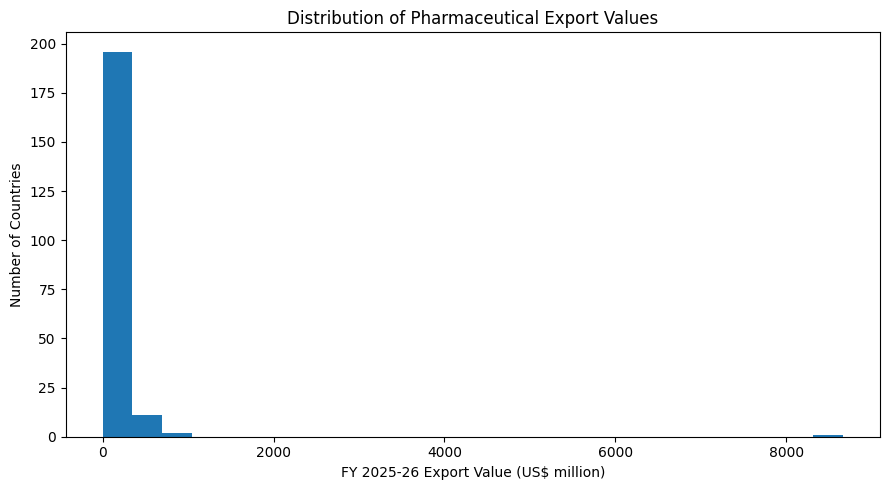

/tmp/ipykernel_746/4227643298.py:376: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


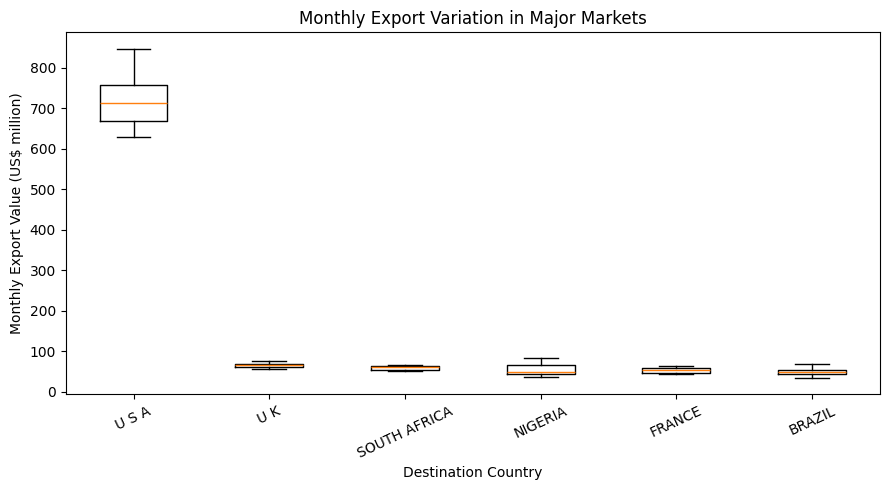


Simple Linear Regression Results
--------------------------------
Slope: 0.7034139992650038
Intercept: 502.1318483689188
MAE: 231.32065818544564
RMSE: 349.9341887416308
R-squared: -0.91436902908359

Actual vs Predicted:
        Date  Actual_Export_USD_Mn  Predicted_Export_USD_Mn
0 2024-11-01              1719.148              1977.361231
1 2024-12-01              1983.879              1711.404618
2 2025-01-01              2083.567              1897.620110
3 2025-02-01              1991.829              1967.742045
4 2025-03-01              3035.863              1903.212251
5 2025-04-01              2022.214              2637.600382
6 2025-05-01              1995.606              1924.585485
7 2025-06-01              2115.975              1905.869046
8 2025-07-01              2160.278              1990.538285
9 2025-08-01              2022.977              2021.701636


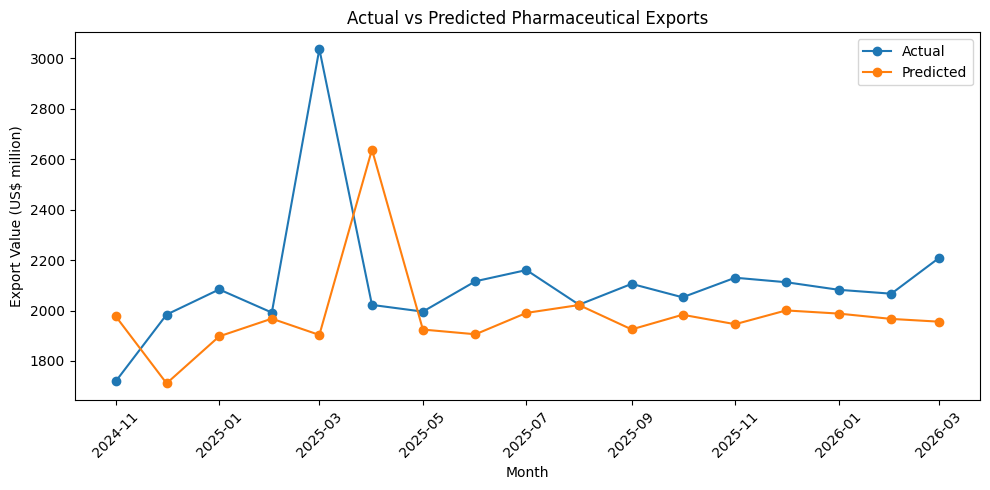


Analysis completed successfully.


In [1]:
# MGNM801 – Business Analytics
# Indian Pharmaceutical Export Market Analysis
# HS Code 30 – Pharmaceutical Products
# Source: Government of India, Ministry of Commerce & Industry, DGCIS / TRADESTAT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


# 1. LOAD THE EXTERNAL DATA

df = pd.read_csv("DGCIS_DATA.csv")

print("First five rows:")
print(df.head())

print("\nData information:")
print(df.info())

print("\nDescriptive statistics:")
print(df.describe())

# 2. SELECT MONTHLY USD COLUMNS

usd_columns = []

for column in df.columns:
    if column.endswith("_USD_Mn"):
        usd_columns.append(column)

print("\nNumber of monthly USD columns:", len(usd_columns))

# 3. REMOVE TOTAL ROW

df = df[df["Country Name"].str.upper() != "TOTAL"].copy()

# 4. CONVERT WIDE DATA INTO LONG FORMAT

records = []

for i in range(len(df)):

    country = str(df.iloc[i]["Country Name"]).strip()

    for column in usd_columns:

        parts = column.replace("_USD_Mn", "").split("-", 1)

        month = parts[0]
        fy = parts[1]

        value = str(df.iloc[i][column]).replace(",", "").strip()

        if value == "" or value == "nan":
            value = np.nan
        else:
            value = float(value)

        records.append([country, fy, month, value])

data = pd.DataFrame(
    records,
    columns=["Country", "FY", "Month", "Export_USD_Mn"]
)

print("\nLong-format data:")
print(data.head())

# 5. REMOVE INCOMPLETE FINANCIAL YEAR

data = data[data["FY"] != "2026-27"].copy()

# 6. DATA TYPE CHECK

data["Export_USD_Mn"] = pd.to_numeric(
    data["Export_USD_Mn"],
    errors="coerce"
)

print("\nMissing values:")
print(data.isna().sum())

print("\nDuplicate rows:")
print(data.duplicated(["Country", "FY", "Month"]).sum())

# Remove missing export values
data = data.dropna(subset=["Export_USD_Mn"])

# 7. CREATE MONTH VARIABLES

month_number = {
    "April": 1,
    "May": 2,
    "June": 3,
    "July": 4,
    "August": 5,
    "September": 6,
    "October": 7,
    "November": 8,
    "December": 9,
    "January": 10,
    "February": 11,
    "March": 12
}

calendar_month = {
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
    "January": 1,
    "February": 2,
    "March": 3
}

data["Month_Number"] = data["Month"].map(month_number)
data["Calendar_Month"] = data["Month"].map(calendar_month)

data["FY_Start"] = data["FY"].str[:4].astype(int)

data["Calendar_Year"] = np.where(
    data["Calendar_Month"] >= 4,
    data["FY_Start"],
    data["FY_Start"] + 1
)

data["Date"] = pd.to_datetime(
    data["Calendar_Year"].astype(str)
    + "-"
    + data["Calendar_Month"].astype(str)
    + "-01"
)

data = data.sort_values(["Country", "Date"])

print("\nNumber of countries:", data["Country"].nunique())
print("Number of observations:", len(data))

# 8. MONTHLY TOTAL PHARMACEUTICAL EXPORTS

monthly = (
    data.groupby("Date")["Export_USD_Mn"]
    .sum()
    .reset_index()
)

monthly.columns = [
    "Date",
    "Total_Export_USD_Mn"
]

monthly = monthly.sort_values("Date")

# Previous month export for simple forecasting
monthly["Previous_Month_Export"] = (
    monthly["Total_Export_USD_Mn"].shift(1)
)

monthly["Growth_%"] = (
    monthly["Total_Export_USD_Mn"].pct_change() * 100
)

print("\nMonthly summary:")
print(monthly.head())

# 9. FINANCIAL-YEAR SUMMARY

def get_fy(date):

    if date.month >= 4:
        return str(date.year) + "-" + str(date.year + 1)[-2:]
    else:
        return str(date.year - 1) + "-" + str(date.year)[-2:]


monthly["FY"] = monthly["Date"].apply(get_fy)

annual = (
    monthly.groupby("FY")["Total_Export_USD_Mn"]
    .sum()
    .reset_index()
)

annual["Growth_%"] = (
    annual["Total_Export_USD_Mn"].pct_change() * 100
)

print("\nFinancial-year summary:")
print(annual)

# 10. COUNTRY-WISE FINANCIAL-YEAR SUMMARY

country_fy = (
    data.groupby(["Country", "FY"])["Export_USD_Mn"]
    .sum()
    .reset_index()
)

country_pivot = country_fy.pivot(
    index="Country",
    columns="FY",
    values="Export_USD_Mn"
).fillna(0)

# Growth between FY 2024-25 and FY 2025-26
country_pivot["Growth_25_26_%"] = (
    (country_pivot["2025-26"] - country_pivot["2024-25"])
    / country_pivot["2024-25"]
) * 100

# 11. MARKET SHARE

total_25_26 = annual.loc[
    annual["FY"] == "2025-26",
    "Total_Export_USD_Mn"
].iloc[0]

country_pivot["Share_25_26_%"] = (
    country_pivot["2025-26"] / total_25_26
) * 100

# 12. MARKET STABILITY

latest = data[data["FY"] == "2025-26"].copy()

stability = latest.groupby("Country")["Export_USD_Mn"].agg(
    ["mean", "std"]
)

stability["CV_%"] = (
    stability["std"] / stability["mean"]
) * 100

market = country_pivot.join(stability["CV_%"])

print("\nTop 10 pharmaceutical export markets:")
print(
    market.sort_values(
        "2025-26",
        ascending=False
    ).head(10)
)

# 13. DESCRIPTIVE STATISTICS

print("\nOverall descriptive statistics:")
print(data["Export_USD_Mn"].describe())

print("\nCorrelation between monthly export and previous month:")
print(
    monthly[
        ["Total_Export_USD_Mn", "Previous_Month_Export"]
    ].corr()
)

# 14. VISUALISATION 1 – MONTHLY LINE CHART

plt.figure(figsize=(10, 5))

plt.plot(
    monthly["Date"],
    monthly["Total_Export_USD_Mn"],
    marker="o"
)

plt.title("India's Monthly Pharmaceutical Exports")
plt.xlabel("Month")
plt.ylabel("Export Value (US$ million)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 15. VISUALISATION 2 – FINANCIAL-YEAR BAR CHART

plt.figure(figsize=(9, 5))

plt.bar(
    annual["FY"],
    annual["Total_Export_USD_Mn"]
)

plt.title("Pharmaceutical Exports by Financial Year")
plt.xlabel("Financial Year")
plt.ylabel("Export Value (US$ million)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 16. VISUALISATION 3 – TOP 10 MARKETS

top10 = (
    market.sort_values(
        "2025-26",
        ascending=False
    ).head(10)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top10.index,
    top10["2025-26"]
)

plt.title("Top 10 Pharmaceutical Export Markets – FY 2025-26")
plt.xlabel("Export Value (US$ million)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 17. VISUALISATION 4 – PIE CHART

top10_value = top10["2025-26"].sum()
other_value = total_25_26 - top10_value

plt.figure(figsize=(6, 6))

plt.pie(
    [top10_value, other_value],
    labels=["Top 10 markets", "Other markets"],
    autopct="%1.1f%%"
)

plt.title("Top 10 Market Share – FY 2025-26")
plt.show()

# 18. VISUALISATION 5 – HISTOGRAM

values = market[
    market["2025-26"] > 0
]["2025-26"]

plt.figure(figsize=(9, 5))

plt.hist(
    values,
    bins=25
)

plt.title("Distribution of Pharmaceutical Export Values")
plt.xlabel("FY 2025-26 Export Value (US$ million)")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

# 19. VISUALISATION 6 – BOX PLOT

top6 = market.sort_values(
    "2025-26",
    ascending=False
).head(6).index

box_data = []

for country in top6:

    values = latest[
        latest["Country"] == country
    ]["Export_USD_Mn"]

    box_data.append(values)

plt.figure(figsize=(9, 5))

plt.boxplot(
    box_data,
    labels=top6
)

plt.title("Monthly Export Variation in Major Markets")
plt.xlabel("Destination Country")
plt.ylabel("Monthly Export Value (US$ million)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# 20. PREDICTIVE ANALYTICS – SIMPLE LINEAR REGRESSION

# Target: Current month's pharmaceutical export

# Predictor: Previous month's pharmaceutical export

# The first 80% of observations are used for training and the remaining 20% are used for testing.

model_data = monthly[
    ["Date", "Total_Export_USD_Mn", "Previous_Month_Export"]
].dropna().copy()

X = model_data["Previous_Month_Export"].values
y = model_data["Total_Export_USD_Mn"].values

split_point = int(len(model_data) * 0.80)

X_train = X[:split_point]
y_train = y[:split_point]

X_test = X[split_point:]
y_test = y[split_point:]

# Simple linear regression using SciPy
result = linregress(
    X_train,
    y_train
)

slope = result.slope
intercept = result.intercept

# Predictions for test data
y_pred = intercept + slope * X_test

# 21. MODEL EVALUATION

mae = np.mean(
    np.abs(y_test - y_pred)
)

rmse = np.sqrt(
    np.mean((y_test - y_pred) ** 2)
)

# R-squared for test data
ss_total = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

ss_error = np.sum(
    (y_test - y_pred) ** 2
)

r2 = 1 - (ss_error / ss_total)

print("\nSimple Linear Regression Results")
print("--------------------------------")
print("Slope:", slope)
print("Intercept:", intercept)
print("MAE:", mae)
print("RMSE:", rmse)
print("R-squared:", r2)

# 22. ACTUAL VS PREDICTED VALUES

prediction_table = pd.DataFrame({
    "Date": model_data["Date"].iloc[split_point:].values,
    "Actual_Export_USD_Mn": y_test,
    "Predicted_Export_USD_Mn": y_pred
})

print("\nActual vs Predicted:")
print(prediction_table.head(10))

plt.figure(figsize=(10, 5))

plt.plot(
     prediction_table["Date"],
     prediction_table["Actual_Export_USD_Mn"],
     marker="o",
     label="Actual"
 )

plt.plot(
    prediction_table["Date"],
     prediction_table["Predicted_Export_USD_Mn"],
    marker="o",
     label="Predicted"
 )

plt.title("Actual vs Predicted Pharmaceutical Exports")
plt.xlabel("Month")
plt.ylabel("Export Value (US$ million)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 23. SAVE IMPORTANT OUTPUTS

data.to_csv(
         "pharma_exports_long_basic.csv",
     index=False
         )

annual.to_csv(
     "pharma_annual_summary.csv",
     index=False
     )

market.to_csv(
     "pharma_market_summary.csv"
      )

prediction_table.to_csv(
         "pharma_regression_predictions.csv",
         index=False
         )
print("\nAnalysis completed successfully.")